Data Collection

In [1]:
import yfinance as yf

ticker='MSFT'
data=yf.download(ticker,start='2015-01-01',end='2026-03-01')
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           MSFT       MSFT       MSFT       MSFT      MSFT
Date                                                            
2015-01-02  39.767696  40.329003  39.580597  39.682651  27913900
2015-01-05  39.401993  39.742176  39.333954  39.436009  39673900
2015-01-06  38.823673  39.759182  38.730122  39.444511  36447900
2015-01-07  39.316952  39.512558  38.687610  39.104336  29114100
2015-01-08  40.473576  40.609650  39.733673  39.759186  29645200


In [2]:
data.shape

(2805, 5)

Dataset Cleaning

In [3]:
data.columns=[col[0] for col in data.columns] #level 0 columns selected
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,39.767696,40.329003,39.580597,39.682651,27913900
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200


In [4]:
print(data.columns)     # date is not in the columns
print(type(data.columns))

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
<class 'pandas.Index'>


In [5]:
import pandas as pd
data.index=pd.to_datetime(data.index) # datetime object
print(type(data.index))

<class 'pandas.DatetimeIndex'>


In [6]:
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,39.767696,40.329003,39.580597,39.682651,27913900
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200


In [7]:
print(data.index.name)
print(data.index.dtype)
print(data.columns)

Date
datetime64[s]
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [8]:
data.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
data.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

EDA

In [10]:
import plotly.graph_objects as go

fig=go.Figure()
fig.add_trace(go.Scatter(x=data.index,y=data['Open'],mode='lines',name='Open Price'))   # Open Price
fig.add_trace(go.Scatter(x=data.index,y=data['Close'],mode='lines',name='Close Price')) # Close Price

fig.update_layout(title='Microsoft Open vs Closing Stock Price',xaxis_title='Date',yaxis_title='Price($)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()


In [11]:
data.describe()

,Close,High,Low,Open,Volume
count,2805.000000,2805.000000,2805.000000,2805.000000,2.805000e+03
mean,208.874630,210.784670,206.791018,208.849066,2.841112e+07
std,144.511902,145.726534,143.222832,144.556130,1.328486e+07
min,34.358738,34.894478,34.214161,34.520328,5.855900e+06
25%,70.751877,70.870598,70.532769,70.687984,2.012900e+07
50%,194.987411,198.705302,192.957048,195.549472,2.520130e+07
75%,318.266266,322.060239,314.829546,319.085929,3.279080e+07
max,539.825256,552.242002,538.530652,552.023241,1.691640e+08


In [12]:
# Daily Returns 
data['Daily Returns']=data['Close'].pct_change() # % change between current value & Previous value
data.head()

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2015-01-02,39.767696,40.329003,39.580597,39.682651,27913900,NaN
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900,-0.009196
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900,-0.014677
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100,0.012706
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200,0.029418


In [13]:
data=data.dropna()
data.head()

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900,-0.009196
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900,-0.014677
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100,0.012706
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200,0.029418
2015-01-09,40.133377,40.669170,39.886745,40.490573,23944200,-0.008405


In [14]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=data.index,y=data['Daily Returns'],mode='lines'))
fig.update_layout(title='Daily Returns',xaxis_title='Date',yaxis_title='Daily Returns',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

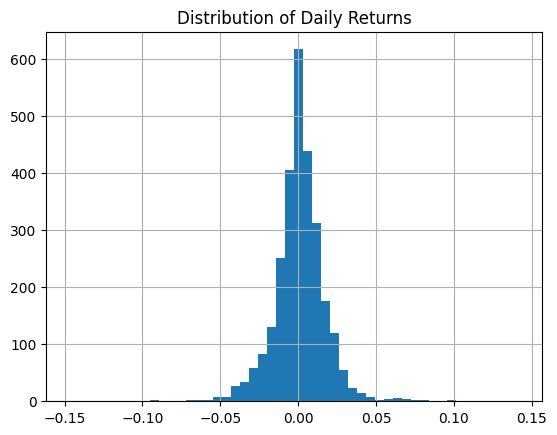

In [15]:
import matplotlib.pyplot as plt
data['Daily Returns'].hist(bins=50)
plt.title('Distribution of Daily Returns')
plt.show()


In [16]:
data['Daily Returns %']=data['Daily Returns']*100
data=data.drop(columns='Daily Returns')
data.head()

,Close,High,Low,Open,Volume,Daily Returns %
Date,,,,,,
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900,-0.919600
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900,-1.467742
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100,1.270561
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200,2.941794
2015-01-09,40.133377,40.669170,39.886745,40.490573,23944200,-0.840545


In [17]:
data['Daily Returns %'].describe()

count    2804.000000
mean        0.096250
std         1.706111
min       -14.739043
25%        -0.679652
50%         0.091883
75%         0.941811
max        14.216879
Name: Daily Returns %, dtype: float64

In [18]:
data.loc[data['Daily Returns %'].idxmax()]
# Highest daily return percentage
# Friday, March 13, 2020 was the day that POTUS(President of the united states) declared a National Emergency for the COVID pandemic

Close              1.508737e+02
High               1.537994e+02
Low                1.336804e+02
Open               1.401112e+02
Volume             9.272740e+07
Daily Returns %    1.421688e+01
Name: 2020-03-13 00:00:00, dtype: float64

In [19]:
data.loc[data['Daily Returns %'].idxmin()]
# lowest daily return %
# peak of COVID

Close              1.286363e+02
High               1.418685e+02
Low                1.282374e+02
Open               1.329869e+02
Volume             8.790590e+07
Daily Returns %   -1.473904e+01
Name: 2020-03-16 00:00:00, dtype: float64

In [20]:
data.nlargest(2,'Daily Returns %').iloc[-1]

Close              4.100144e+01
High               4.123270e+01
Low                3.909997e+01
Open               3.910854e+01
Volume             1.309337e+08
Daily Returns %    1.045223e+01
Name: 2015-04-24 00:00:00, dtype: float64

In [21]:
data.nsmallest(2,'Daily Returns %').iloc[-1]
# fifth and final release of epstien files

Close              4.325128e+02
High               4.414923e+02
Low                4.200612e+02
Open               4.389880e+02
Volume             1.288553e+08
Daily Returns %   -9.993146e+00
Name: 2026-01-29 00:00:00, dtype: float64

Comparison

In [22]:
# Apple Stock Data
apple_data=yf.download('AAPL',start='2015-01-01',end='2026-03-01')
apple_data.columns=[col[0] for col in apple_data.columns]
apple_data.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [23]:
apple_data.index=pd.to_datetime(apple_data.index) # datetime object
print(type(apple_data.index))

<class 'pandas.DatetimeIndex'>


In [24]:
apple_data

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000
...,...,...,...,...,...
2026-02-23,266.179993,269.429993,263.380005,263.489990,37308200
2026-02-24,272.140015,274.890015,267.709991,267.859985,47014600
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300


In [25]:
# Google 
google_data=yf.download('GOOG',start='2015-01-01',end='2026-03-01')
google_data.columns=[col[0] for col in google_data.columns]
google_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955559,26.275053,25.920445,26.163278,28951268
2015-01-05,25.414503,25.931824,25.374444,25.878904,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782934,25.086798,24.711221,25.074730,41301082
2015-01-08,24.861076,24.900642,24.283418,24.629123,67071641
...,...,...,...,...,...
2026-02-23,311.470581,319.230099,309.771766,318.915349,17641200
2026-02-24,310.701141,312.150102,305.874524,310.421340,15040700
2026-02-25,312.809631,313.439193,309.142202,311.900268,20209100


In [26]:
# Tesla 
tesla_data=yf.download('TSLA',start='2015-01-01',end='2026-03-01')
tesla_data.columns=[col[0] for col in tesla_data.columns]
tesla_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500
...,...,...,...,...,...
2026-02-23,399.829987,407.700012,394.040009,407.290009,69680000
2026-02-24,409.380005,410.820007,397.640015,399.500000,58579500
2026-02-25,417.399994,420.339996,412.149994,412.149994,54809700


In [27]:
# Reliance Data 
reliance_data=yf.download('RELIANCE.NS',start='2015-01-01',end='2026-03-01')
reliance_data.columns=[col[0] for col in reliance_data.columns]
reliance_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,189.999817,190.877171,189.090366,189.657446,2963643
2015-01-02,189.496948,191.743828,189.229471,190.042616,7331366
2015-01-05,187.421249,190.641775,187.046767,189.379239,10103941
2015-01-06,178.915222,186.811376,178.037869,186.169417,18627980
2015-01-07,182.809799,183.772746,179.107815,179.129214,20720312
...,...,...,...,...,...
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856
2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409
2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792


# Comparison Graph

In [28]:
fig=go.Figure()

fig.add_trace(go.Scattergl(x=data.index,y=data['Open'],mode='lines',name='MicroSoft'))

fig.add_trace(go.Scattergl(x=apple_data.index,y=apple_data['Open'],mode='lines',name='Apple'))

fig.add_trace(go.Scattergl(x=tesla_data.index,y=tesla_data['Open'],mode='lines',name='Tesla'))

fig.add_trace(go.Scattergl(x=google_data.index,y=google_data['Open'],mode='lines',name='Google'))

fig.update_layout(title='Open Price',xaxis_title='Date',yaxis_title='Price($)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

In [29]:
fig=go.Figure()

fig.add_trace(go.Scattergl(x=data.index,y=data['Close'],mode='lines',name='MicroSoft'))

fig.add_trace(go.Scattergl(x=apple_data.index,y=apple_data['Close'],mode='lines',name='Apple'))

fig.add_trace(go.Scattergl(x=tesla_data.index,y=tesla_data['Close'],mode='lines',name='Tesla'))

fig.add_trace(go.Scattergl(x=google_data.index,y=google_data['Close'],mode='lines',name='Google'))

fig.update_layout(title='Close Price',xaxis_title='Date',yaxis_title='Price($)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

In [30]:
fig=go.Figure()

fig.add_trace(go.Scatter(x=reliance_data.index,y=reliance_data['Open'],mode='lines',name='Reliance Open Price'))
fig.add_trace(go.Scatter(x=reliance_data.index,y=reliance_data['Close'],mode='lines',name='Reliance Close Price'))

fig.update_layout(title='Reliance Open vs Close Price',xaxis_title='Date',yaxis_title='Price(INR)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

Moving Averages

In [31]:
data['MA20']=data['Close'].rolling(window=20).mean()
data['MA50']=data['Close'].rolling(window=50).mean()
data['MA200']=data['Close'].rolling(window=200).mean()

In [32]:
fig=go.Figure()

fig.add_trace(go.Scatter(x=data.index,y=data['Close'],mode='lines',name='Close Price'))
fig.add_trace(go.Scatter(x=data.index,y=data['MA20'],mode='lines',name='MA20'))
fig.add_trace(go.Scatter(x=data.index,y=data['MA50'],mode='lines',name='MA50'))
fig.add_trace(go.Scatter(x=data.index,y=data['MA200'],mode='lines',name='MA200'))

fig.update_layout(title='Moving Averages vs Close Price',xaxis_title='Date',yaxis_title='Price($)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

* MA200 is upward meaning long term grwoth momentum
* MA20 closely follows close price, short term momentum shifts
* long term sentiments remains positive
* Bullish trend, MA20 > MA50 > MA200

LSTM

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,Flatten
from tensorflow.keras.callbacks import EarlyStopping 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [34]:
data.dtypes

Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
Daily Returns %    float64
MA20               float64
MA50               float64
MA200              float64
dtype: object

In [41]:
data=data.drop(columns=['Daily Returns %','MA20','MA50','MA200'])
data

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-05,39.401993,39.742176,39.333954,39.436009,39673900
2015-01-06,38.823673,39.759182,38.730122,39.444511,36447900
2015-01-07,39.316952,39.512558,38.687610,39.104336,29114100
2015-01-08,40.473576,40.609650,39.733673,39.759186,29645200
2015-01-09,40.133377,40.669170,39.886745,40.490573,23944200
...,...,...,...,...,...
2026-02-23,384.470001,395.359985,383.100006,395.000000,43238300
2026-02-24,389.000000,389.359985,381.709991,384.140015,33884700
2026-02-25,400.600006,401.470001,390.160004,390.529999,43625500


In [55]:
train_size=int(len(data)*0.80) # 80% of the data
train_data=data[:train_size] # 80
test_data=data[train_size:]  # 20  
print(train_data.shape)
print(test_data.shape)

(2243, 5)
(561, 5)


In [56]:
scaler=MinMaxScaler()
train_data=data['Close'][:train_size].values.reshape(-1,1)
test_data=data['Close'][train_size:].values.reshape(-1,1)

In [57]:
train_data

array([[ 39.4019928 ],
       [ 38.82367325],
       [ 39.31695175],
       ...,
       [376.21911621],
       [372.43432617],
       [372.49325562]], shape=(2243, 1))

In [58]:
test_data

array([[368.16781616],
       [362.88876343],
       [366.21151733],
       [362.55450439],
       [364.66815186],
       [367.89257812],
       [365.012146  ],
       [368.04000854],
       [368.0302124 ],
       [359.73309326],
       [364.45187378],
       [366.33929443],
       [366.93893433],
       [364.34365845],
       [367.2142334 ],
       [368.23657227],
       [368.3152771 ],
       [367.73532104],
       [368.92477417],
       [369.67193604],
       [364.5894165 ],
       [364.32400513],
       [361.70907593],
       [361.52227783],
       [368.3447876 ],
       [369.42617798],
       [376.28796387],
       [378.11645508],
       [381.89141846],
       [383.66091919],
       [382.87451172],
       [387.19995117],
       [391.91870117],
       [389.7953186 ],
       [392.14480591],
       [395.74282837],
       [398.01370239],
       [397.08953857],
       [402.78152466],
       [401.67068481],
       [390.84716797],
       [396.94210815],
       [404.25613403],
       [398

In [59]:
scaled_train=scaler.fit_transform(train_data)
scaled_test=scaler.fit_transform(test_data)

In [60]:
print(scaled_train.shape)
print(scaled_test.shape)

(2243, 1)
(561, 1)


In [97]:
n_input=60   # 2 monthslookback window
n_feature=1  # Close Price
batch_size=32

In [98]:
train_generator=TimeseriesGenerator(scaled_train,scaled_train,length=n_input,batch_size=batch_size) # target = same array, shifted internally
test_generator=TimeseriesGenerator(scaled_test,scaled_test,length=n_input,batch_size=batch_size)

In [99]:
# sanity check
x,y=train_generator[0]
print(x.shape)
print(y.shape)

(32, 60, 1)
(32, 1)


In [100]:
model=Sequential()
model.add(LSTM(64,activation='tanh',return_sequences=True,input_shape=(n_input,n_feature)))
model.add(Dropout(0.3))
model.add(LSTM(32,activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(1))

In [126]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),loss='mean_squared_error',metrics=['mae'])

In [127]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
callbacks=EarlyStopping(monitor='val_loss',patience=20)

In [129]:
f=model.fit(train_generator,validation_data=test_generator,epochs=100,shuffle=False,callbacks=callbacks)

Epoch 1/100


69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.0021 - mae: 0.0332 - val_loss: 0.0016 - val_mae: 0.0291
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0013 - mae: 0.0267 - val_loss: 0.0015 - val_mae: 0.0282
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0013 - mae: 0.0270 - val_loss: 0.0015 - val_mae: 0.0286
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - mae: 0.0280 - val_loss: 0.0017 - val_mae: 0.0292
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0016 - mae: 0.0299 - val_loss: 0.0019 - val_mae: 0.0327
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - mae: 0.0288 - val_loss: 0.0019 - val_mae: 0.0317
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0014 - mae: 0.0281 - val_loss: 0.0016 - val_mae: 0.0284
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0014 - mae: 0.0278 - val_loss: 0.0016 - val_mae: 0.0284
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 -

In [130]:
final=f.history
final.keys()
print(f'Validation Loss : {final['val_loss'][-1]}')
print(f'Mean Absolute Error : {final['val_mae'][-1]}')


Validation Loss : 0.001542705693282187
Mean Absolute Error : 0.028769945725798607


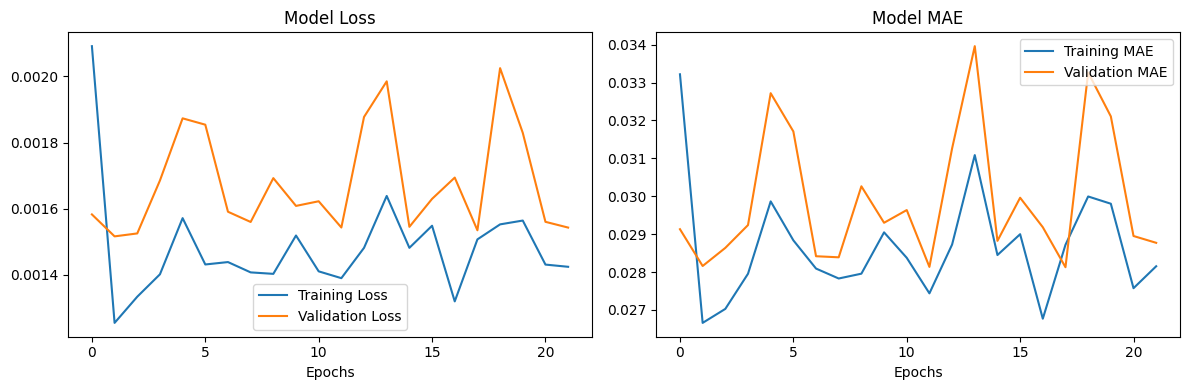

In [131]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(final['loss'],label='Training Loss')
plt.plot(final['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(final['mae'],label='Training MAE')
plt.plot(final['val_mae'],label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()